Compare different CV with deepLDA CV

## Setup

In [1]:
import os
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import plumed
import math

In [2]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
TEST_NUM_STEPS   = 10_000     # for testing  
#NUM_STEPS   = 500_000    # productions
NUM_STEPS   = 10_000_000    # 20ns
STRIDE      = 10
#STRIDE      = 100

num_steps   = NUM_STEPS
test_num_steps = TEST_NUM_STEPS

os.chdir(BASE_DIR)

In [3]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [4]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# delete outputs of simulations from `folder``
def clean_true(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

### biased simulation using $\phi$

In [5]:
# CREATE FOLDER AND COPY INPUTS
folder_phi = DATA_DIR / "2_biased-phi/"
Path(folder_phi).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_phi)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_phi)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [29]:
# WRITE PLUMED INPUT FILE
with open(folder_phi / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
#INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Activate well-tempered metadynamics in phi
metad: METAD ARG=phi ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=phi,psi
ENDPLUMED
""")

In [37]:
clean(folder_phi) # note: this deletes all previous results in folder!

In [31]:
# RUN GROMACS

execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {test_num_steps} > alanine.out", folder=folder_phi)

Completed: gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000 > alanine.out


In [33]:
# print command to run in terminal (for longer run)

print(f"cd {folder_phi}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/2_biased-phi
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 500000 -v


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++


Text(0, 0.5, 'phi [rad]')

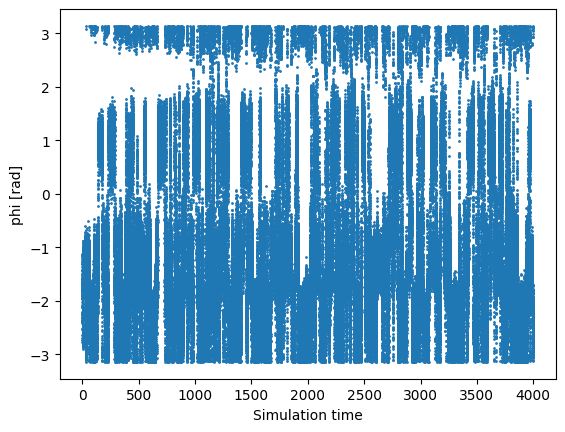

In [6]:
# visualize CV file
data=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
# plot phi during simulation (first 200k points)
plt.plot(data["time"][:200000],data["phi"][:200000],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'phi [rad]')

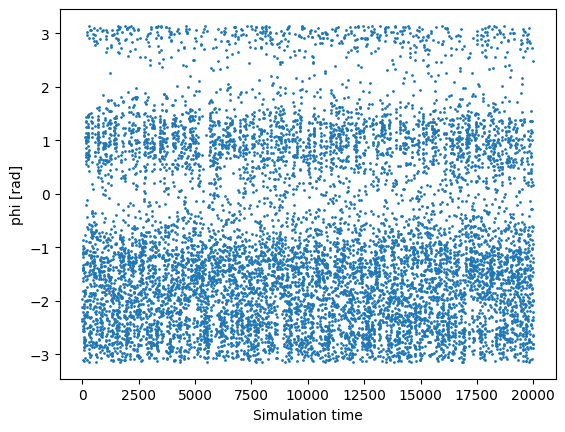

In [7]:
plt.plot(data["time"][::100],data["phi"][::100],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++


Text(0, 0.5, 'height [kj/mol]')

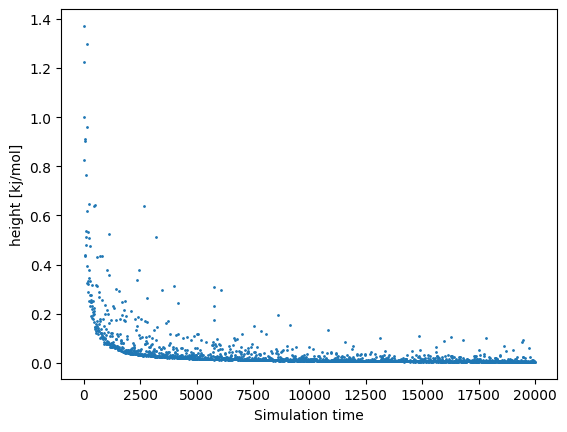

In [8]:
# visualize CV file
data=plumed.read_as_pandas(str(folder_phi /"HILLS"))
# plot phi during simulation (first 200k points)
plt.plot(data["time"][::10],data["height"][::10],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("height [kj/mol]")

In [9]:
data_phi=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
data_phi.head()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++


,time,phi,psi
0,0.00,-2.36867,2.64432
1,0.02,-2.38391,2.56521
2,0.04,-2.22548,2.51866
3,0.06,-2.29910,2.43971
4,0.08,-2.21197,2.34191


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++


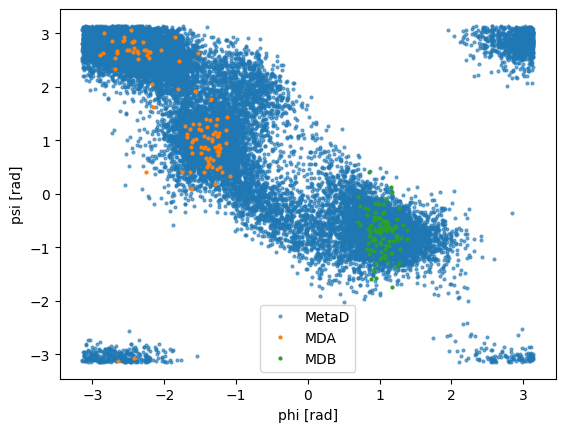

In [11]:
folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

dataA = plumed.read_as_pandas(str(folderA / "COLVAR"))
dataB = plumed.read_as_pandas(str(folderB / "COLVAR"))
data_phi=plumed.read_as_pandas(str(folder_phi /"COLVAR"))

# plot phi vs psi
plt.plot(data_phi["phi"][::50],data_phi["psi"][::50],'o', alpha=0.6, ms=2, label="MetaD")
plt.plot(dataA["phi"][::50],dataA["psi"][::50],'o', ms=2, label="MDA")
plt.plot(dataB["phi"][::50],dataB["psi"][::50],'o', ms=2, label="MDB")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("psi [rad]")
plt.legend()

In [ ]:
# compute free energy as a function of simulation time

#plumed sum_hills --hills HILLS --stride 200 --mintozero
execute("plumed sum_hills --hills HILLS --stride 200 --mintozero", folder=folder_phi)

Completed: plumed sum_hills --hills HILLS --stride 20 --mintozero


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.

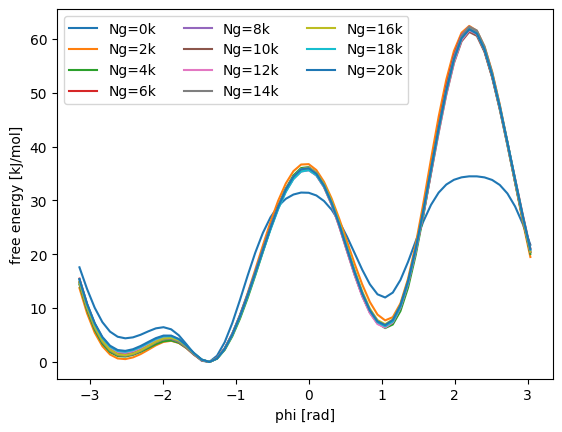

In [12]:
# plot free energy as a function of simulation time
#for i in range(0,51,10):
for i in range(0,101,10):    
 # import fes file into pandas dataset
 data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 # plot fes
 plt.plot(data["phi"],data["file.free"], label="Ng="+str(int(2*i/10))+"k") 
# labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend(ncol=3)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.

Text(0, 0.5, 'DeltaF [kJ/mol]')

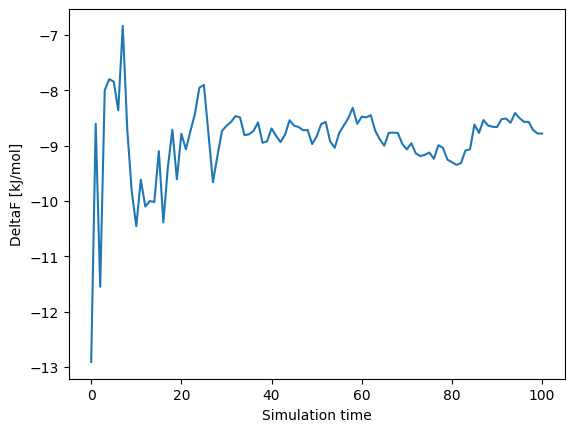

In [14]:
# calculate free-energy difference
DeltaF=[]; kbt=2.494339
# cycle on free-energy profiles
#for i in range(0,51):
for i in range(0,101):   
 # import fes file into pandas dataset
 data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 # find minimum value of fes
 minf = min(data["file.free"])
 # plot fes
 F0=0.0; F1=0.0
 for j in range(0, len(data["phi"])):
     phi = data["phi"][j]
     # calculate probability
     p = math.exp((-data["file.free"][j]+minf)/kbt)
     # integrate in the two basins
     if(-3<=phi<=-1):   F0 += p
     if(0.5<=phi<=1.5): F1 += p
 # calculate free energy difference and add to list
 DeltaF.append(-kbt*math.log(F0/F1))         
# plot
plt.plot(DeltaF) 
# labels
plt.xlabel("Simulation time")
plt.ylabel("DeltaF [kJ/mol]")

In [ ]:
folder2 = DATA_DIR / "2_biased_phi-hills/"
Path(folder2).mkdir(parents=True, exist_ok=True)